In [20]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


In [21]:
gap_y1 = np.array([0.1 + 0.1j])
gap_y2 = np.array([0.2 + 0.2j])
gap_uu_y = np.array([0.3 + 0.3j])
gap_dd_y = np.array([0.4 + 0.4j])

i=0
block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[2, 1] += -gap_y1[i].conj()
block[3, 0] += gap_y2[i].conj()

block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2, 0] += gap_uu_y[i].conj()
block[3, 1] += gap_dd_y[i].conj()
print(block)

block = np.zeros((4, 4), dtype=np.complex128)

block[0, 3] += gap_y2[i]
block[1, 2] += -gap_y1[i]
block[0, 2] += gap_uu_y[i]
block[1, 3] += gap_dd_y[i]
block[2:, :2] = block[:2,2:].conj().T
print(block)

[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j   0.3+0.3j  0.2+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.1j  0.4+0.4j]
 [ 0.3-0.3j -0.1+0.1j  0. +0.j   0. +0.j ]
 [ 0.2-0.2j  0.4-0.4j  0. +0.j   0. +0.j ]]


In [22]:
X, Y = 30, 30
lattice = Lattice(X, Y)

t = 1
mu = -1 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 2.0 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, U=None, V_prime=None, V=V, F_init=[0.1, -0.1, 0.1j, - 0.1j])

In [23]:
print(is_hermitian(H.matrix))
print(is_hermitian(H.build_Hk(PI/3)))

True
True


In [24]:
bdg_self_consistency(H, maxiter=50, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS

Iteration 1:
F0:
Absolute error: 2.0312751224753184e-16
Relative error: 0.00020312751224753182
Average_old: 0j
Average_new: (4.675621868843738e-18+0j)
F_xplus:
Absolute error: 0.36331704900466266
Relative error: 3.633170490010295
Average_old: (0.09999999999999999+0j)
Average_new: (0.16612010641562358+0j)
F_xmin:
Absolute error: 0.36331704900466283
Relative error: 3.63317049008296
Average_old: (-0.09999999999999999+0j)
Average_new: (-0.16612010641562358+0j)
F_yplus:
Absolute error: 0.4362910253905269
Relative error: 4.362910253905269
Average_old: 0.1j
Average_new: (1.109726098629434e-17+0.17850194318349302j)
F_ymin:
Absolute error: 0.4362910253905269
Relative error: 4.362910253905269
Average_old: -0.1j
Average_new: (1.109726098629434e-17-0.17850194318349302j)
Fuu_xplus:
Absolute error: 1.132748687530582e-16
Relative error: 0.00011327486875305822
Average_old: 0j
Average_new: (-7.138804639602358e-18+0j)
Fuu_xmin:
Absolute error: 9.408820811522004e-17
Relative error: 9.408820811522004e-05


In [25]:
bdg_self_consistency(H, maxiter=1, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 0.008394701278411342
Relative error: 10.968958937581476
Average_old: (-0.00035686542541123835+0j)
Average_new: (0.0003568739077282654+0j)
F_xplus:
Absolute error: 0.0039821797620809484
Relative error: 0.020992315761172116
Average_old: (0.2912890026090295+0j)
Average_new: (0.29097629744769704+0j)
F_xmin:
Absolute error: 0.003983634920548723
Relative error: 0.021285299914101722
Average_old: (-0.2909761506658291+0j)
Average_new: (-0.29128915977282627+0j)
F_yplus:
Absolute error: 0.023981719261333412
Relative error: 0.060316281685051
Average_old: (-0.0010478601130664365+0.32277684557386926j)
Average_new: (0.001047900021216862+0.3227767316819879j)
F_ymin:
Absolute error: 0.023981719261333412
Relative error: 0.060316281685051
Average_old: (-0.0010478601130664365-0.32277684557386926j)
Average_new: (0.001047900021216862-0.3227767316819879j)
Fuu_xplus:
Absolute error: 4.19944246495279e-17
Relative error: 4.19942785513629e-05
Average_old: (4.312725204200172e-19+0

In [26]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))
print(np.mean(H.F0))

True
True
(0.0003568739077282654+0j)


In [27]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [28]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = F_xmin       # site i gets bond (i,i-1).T

print(np.mean(F0))
print(np.mean(Fx_p - Fx_m)/2)
print(np.mean(F_yplus - F_ymin)/2)
print(np.mean(Fx_p + Fx_m - F_yplus - F_ymin)/4)
print(np.mean(Fx_p + Fx_m + F_yplus + F_ymin)/4)

(0.0003568739077282654+0j)
(0.28142830432325294+0j)
0.3227767316819879j
(-0.0005995584058480009+0j)
(0.0004483416153688626+0j)


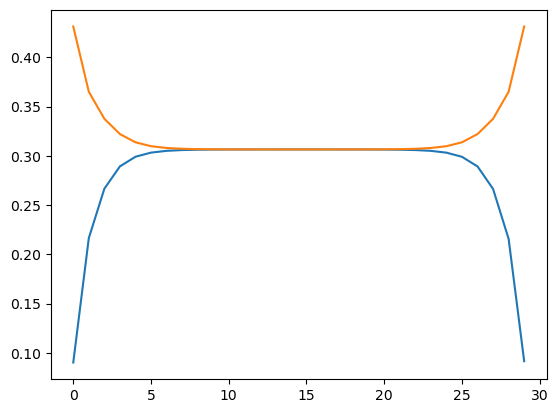

In [33]:
plt.plot(np.real(Fx_p - Fx_m)/2)
plt.plot(np.imag(F_yplus - F_ymin)/2)
# plt.plot(np.real(Fx_p + Fx_m - F_yplus - F_ymin)/4)

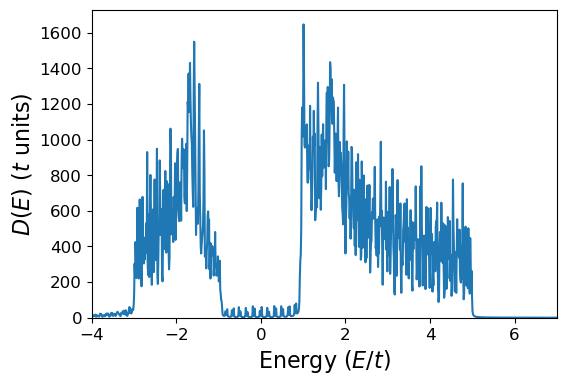

In [30]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [31]:
print(H.free_energy(0))

-4111.498842803111


In [32]:
# %prun H.dos(energies, eta=1e-3)